
# 07 — Decision Support and Economic Evaluation

**Project:** AI-Based Decision Support for Day-Ahead Electricity Price Forecasting in the German Power Market

This notebook converts forecasting outputs into transparent decision recommendations and evaluates their practical value through a scenario-based economic assessment.

## Purpose

This notebook addresses:

- **RQ3:** How does improved forecasting accuracy affect day-ahead bidding or procurement outcomes compared with benchmark strategies?
- **RQ4:** Can an AI-based decision-support framework deliver measurable economic benefits in day-ahead electricity trading?

## Important Scope Note

This is **not** a full trading simulation. It is a transparent decision-support evaluation based on a hypothetical flexible electricity consumer/procurer.

The idea is simple:

- when the model forecasts relatively high prices, reduce or delay flexible consumption;
- when the model forecasts relatively low prices, shift flexible consumption into those hours;
- compare the resulting cost against a no-decision baseline and simpler benchmark strategies.

This keeps the evaluation realistic, understandable and suitable for a master's thesis.


## 1. Import libraries

In [3]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05
)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.frameon": True,
    "figure.autolayout": True
})



## 2. Define paths

This notebook uses the prediction file created in `06_Modeling.ipynb`.

Expected input file:

```text
Results/Modeling/model_predictions_test_set.csv
```

Expected columns:

- actual_price
- naive_24
- rolling_mean_24
- random_forest
- xgboost


In [5]:

PROJECT_ROOT = Path(
    r"C:\Users\SherM\OneDrive\Documents\1. Thesis"
)

PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "Results"
    / "Modeling"
    / "model_predictions_test_set.csv"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "Results"
    / "Decision_Support"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "Figures"
    / "Decision_Support"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Predictions file:", PREDICTIONS_PATH)
print("Results folder:", RESULTS_DIR)
print("Figure folder:", FIGURE_DIR)


Predictions file: C:\Users\SherM\OneDrive\Documents\1. Thesis\Results\Modeling\model_predictions_test_set.csv
Results folder: C:\Users\SherM\OneDrive\Documents\1. Thesis\Results\Decision_Support
Figure folder: C:\Users\SherM\OneDrive\Documents\1. Thesis\Figures\Decision_Support


## 3. Load prediction results

In [28]:
predictions = pd.read_csv(
    PREDICTIONS_PATH,
    index_col=0
).sort_index()

# Force index conversion to proper timezone-aware DatetimeIndex
predictions.index = pd.to_datetime(
    predictions.index,
    utc=True,
    errors="coerce"
)

# Check if any timestamps failed to convert
if predictions.index.isna().any():
    raise ValueError("Some timestamps could not be converted to datetime.")

# Convert from UTC to German local time
predictions.index = predictions.index.tz_convert("Europe/Berlin")

print(predictions.info())
display(predictions.head())
display(predictions.tail())

<class 'pandas.DataFrame'>
DatetimeIndex: 8760 entries, 2024-01-01 00:00:00+01:00 to 2024-12-30 23:00:00+01:00
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   actual_price     8760 non-null   float64
 1   naive_24         8760 non-null   float64
 2   rolling_mean_24  8760 non-null   float64
 3   autoregressive   8760 non-null   float64
 4   random_forest    8760 non-null   float64
 5   xgboost          8760 non-null   float64
dtypes: float64(6)
memory usage: 479.1 KB
None


,actual_price,naive_24,rolling_mean_24,autoregressive,random_forest,xgboost
2024-01-01 00:00:00+01:00,0.10,28.25,9.557500,3.861410,3.737650,2.829680
2024-01-01 01:00:00+01:00,0.01,13.27,8.384583,3.534134,1.454200,1.412234
2024-01-01 02:00:00+01:00,0.00,4.00,7.832083,2.417110,2.828029,1.812522
2024-01-01 03:00:00+01:00,-0.01,0.31,7.665417,1.049796,2.842356,-0.641444
2024-01-01 04:00:00+01:00,-0.03,0.58,7.652083,-0.158092,2.660372,3.737674


,actual_price,naive_24,rolling_mean_24,autoregressive,random_forest,xgboost
2024-12-30 19:00:00+01:00,86.62,121.34,84.176667,-1629.361433,93.611054,90.748270
2024-12-30 20:00:00+01:00,74.83,109.92,82.730000,-1629.840270,79.313946,75.384700
2024-12-30 21:00:00+01:00,68.02,90.21,81.267917,-1630.319232,64.659043,62.974560
2024-12-30 22:00:00+01:00,67.26,83.79,80.343333,-1630.798320,61.659914,63.570934
2024-12-30 23:00:00+01:00,35.66,71.63,79.654583,-1631.277534,55.396490,57.547240


In [30]:

required_columns = [
    "actual_price",
    "naive_24",
    "rolling_mean_24",
    "random_forest",
    "xgboost"
]

missing_columns = [
    column for column in required_columns
    if column not in predictions.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}. "
        "Check the output file from 06_Modeling.ipynb."
    )

print("Prediction file validated successfully.")
print("Test period:", predictions.index.min(), "to", predictions.index.max())
print("Rows:", len(predictions))


Prediction file validated successfully.
Test period: 2024-01-01 00:00:00+01:00 to 2024-12-30 23:00:00+01:00
Rows: 8760



## 4. Define decision-support assumptions

The scenario represents a simple flexible electricity consumer or procurement manager.

### Baseline strategy

The consumer uses a fixed amount of electricity every hour.

### Decision-support strategy

For each day:

- identify the `TOP_K` forecasted most expensive hours;
- identify the `TOP_K` forecasted cheapest hours;
- reduce flexible consumption in expensive hours;
- shift the same amount of energy into cheap hours.

### Key assumptions

- The default demand is `BASE_LOAD_MWH` every hour.
- A flexible portion of `FLEX_MWH_PER_SELECTED_HOUR` can be shifted.
- Total daily energy remains unchanged.
- Network charges, taxes, transaction costs and operational constraints are excluded.
- The result is a scenario-based economic evaluation, not a full trading simulation.

You can later adjust these values for sensitivity analysis.


In [32]:

BASE_LOAD_MWH = 1.0
FLEX_MWH_PER_SELECTED_HOUR = 0.20
TOP_K = 4

PRIMARY_MODEL = "xgboost"

BENCHMARK_MODELS = [
    "naive_24",
    "rolling_mean_24",
    "random_forest",
    "xgboost"
]

print("Base hourly load:", BASE_LOAD_MWH, "MWh")
print("Flexible energy shifted per selected hour:", FLEX_MWH_PER_SELECTED_HOUR, "MWh")
print("High-price hours selected per day:", TOP_K)
print("Low-price hours selected per day:", TOP_K)
print("Primary model:", PRIMARY_MODEL)


Base hourly load: 1.0 MWh
Flexible energy shifted per selected hour: 0.2 MWh
High-price hours selected per day: 4
Low-price hours selected per day: 4
Primary model: xgboost



## 5. Create transparent decision recommendations

The recommendation logic uses daily forecast rankings.

For each model and each day:

- highest forecasted price hours → **Reduce / Avoid**
- lowest forecasted price hours → **Shift / Buy**
- remaining hours → **Hold / Normal**

This is transparent and easy to explain to decision-makers.


In [34]:

def assign_daily_recommendations(
    frame: pd.DataFrame,
    forecast_col: str,
    top_k: int = 4
) -> pd.Series:
    """
    Assign decision recommendations for each day based on forecasted prices.

    Highest forecasted hours:
        Reduce / Avoid

    Lowest forecasted hours:
        Shift / Buy

    Remaining hours:
        Hold / Normal
    """
    recommendations = pd.Series(
        index=frame.index,
        dtype="object"
    )

    for _, day_data in frame.groupby(frame.index.date):
        if len(day_data) < 2:
            recommendations.loc[day_data.index] = "Hold / Normal"
            continue

        k = min(top_k, len(day_data) // 2)

        high_price_hours = (
            day_data[forecast_col]
            .sort_values(ascending=False)
            .head(k)
            .index
        )

        low_price_hours = (
            day_data[forecast_col]
            .sort_values(ascending=True)
            .head(k)
            .index
        )

        recommendations.loc[day_data.index] = "Hold / Normal"
        recommendations.loc[high_price_hours] = "Reduce / Avoid"
        recommendations.loc[low_price_hours] = "Shift / Buy"

    return recommendations


decision_data = predictions.copy()

for model_col in BENCHMARK_MODELS:
    decision_data[f"{model_col}_recommendation"] = assign_daily_recommendations(
        frame=decision_data,
        forecast_col=model_col,
        top_k=TOP_K
    )

display(
    decision_data[
        [
            "actual_price",
            "naive_24",
            "random_forest",
            "xgboost",
            "xgboost_recommendation"
        ]
    ].head(48)
)


,actual_price,naive_24,random_forest,xgboost,xgboost_recommendation
2024-01-01 00:00:00+01:00,0.10,28.25,3.737650,2.829680,Hold / Normal
2024-01-01 01:00:00+01:00,0.01,13.27,1.454200,1.412234,Hold / Normal
2024-01-01 02:00:00+01:00,0.00,4.00,2.828029,1.812522,Hold / Normal
2024-01-01 03:00:00+01:00,-0.01,0.31,2.842356,-0.641444,Shift / Buy
2024-01-01 04:00:00+01:00,-0.03,0.58,2.660372,3.737674,Hold / Normal
2024-01-01 05:00:00+01:00,-0.02,1.28,2.765694,7.710393,Hold / Normal
2024-01-01 06:00:00+01:00,-0.05,0.36,2.632220,9.361908,Hold / Normal
2024-01-01 07:00:00+01:00,-0.02,-0.03,-0.514869,8.549409,Hold / Normal
2024-01-01 08:00:00+01:00,0.00,2.98,0.785660,5.182751,Hold / Normal
2024-01-01 09:00:00+01:00,0.04,9.10,0.071953,-0.273947,Shift / Buy



## 6. Actual high-price and low-price labels

To evaluate whether the recommendations identified valuable periods, we create actual daily labels:

- actual top price hours → Actual High
- actual bottom price hours → Actual Low
- remaining hours → Actual Normal

These labels are only used for retrospective evaluation.


In [36]:

evaluation_frame = decision_data.rename(
    columns={"actual_price": "actual_for_ranking"}
)

decision_data["actual_price_regime"] = assign_daily_recommendations(
    frame=evaluation_frame,
    forecast_col="actual_for_ranking",
    top_k=TOP_K
)

# Rename to more evaluation-focused labels
decision_data["actual_price_regime"] = (
    decision_data["actual_price_regime"]
    .replace({
        "Reduce / Avoid": "Actual High",
        "Shift / Buy": "Actual Low",
        "Hold / Normal": "Actual Normal"
    })
)

display(
    decision_data[
        ["actual_price", "actual_price_regime", "xgboost_recommendation"]
    ].head(48)
)


,actual_price,actual_price_regime,xgboost_recommendation
2024-01-01 00:00:00+01:00,0.10,Actual Normal,Hold / Normal
2024-01-01 01:00:00+01:00,0.01,Actual Normal,Hold / Normal
2024-01-01 02:00:00+01:00,0.00,Actual Normal,Hold / Normal
2024-01-01 03:00:00+01:00,-0.01,Actual Normal,Shift / Buy
2024-01-01 04:00:00+01:00,-0.03,Actual Low,Hold / Normal
2024-01-01 05:00:00+01:00,-0.02,Actual Low,Hold / Normal
2024-01-01 06:00:00+01:00,-0.05,Actual Low,Hold / Normal
2024-01-01 07:00:00+01:00,-0.02,Actual Low,Hold / Normal
2024-01-01 08:00:00+01:00,0.00,Actual Normal,Hold / Normal
2024-01-01 09:00:00+01:00,0.04,Actual Normal,Shift / Buy



## 7. Evaluate high-price detection

A useful decision-support model should correctly identify expensive hours.

This section evaluates whether each forecast model correctly identifies the actual high-price hours within each day.


In [38]:

def evaluate_high_price_detection(
    frame: pd.DataFrame,
    recommendation_col: str
) -> dict:
    """
    Evaluate how well predicted Reduce/Avoid recommendations
    match actual high-price hours.
    """
    y_true = (frame["actual_price_regime"] == "Actual High").astype(int)
    y_pred = (frame[recommendation_col] == "Reduce / Avoid").astype(int)

    return {
        "strategy": recommendation_col.replace("_recommendation", ""),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0)
    }


high_price_detection_results = []

for model_col in BENCHMARK_MODELS:
    high_price_detection_results.append(
        evaluate_high_price_detection(
            frame=decision_data,
            recommendation_col=f"{model_col}_recommendation"
        )
    )

high_price_detection_df = (
    pd.DataFrame(high_price_detection_results)
    .sort_values("f1_score", ascending=False)
    .reset_index(drop=True)
)

display(high_price_detection_df)

high_price_detection_df.to_csv(
    RESULTS_DIR / "high_price_detection_metrics.csv",
    index=False
)


,strategy,accuracy,precision,recall,f1_score
0,xgboost,0.934475,0.803425,0.803425,0.803425
1,random_forest,0.928311,0.784932,0.784932,0.784932
2,naive_24,0.867123,0.601370,0.601370,0.601370
3,rolling_mean_24,0.718950,0.156849,0.156849,0.156849


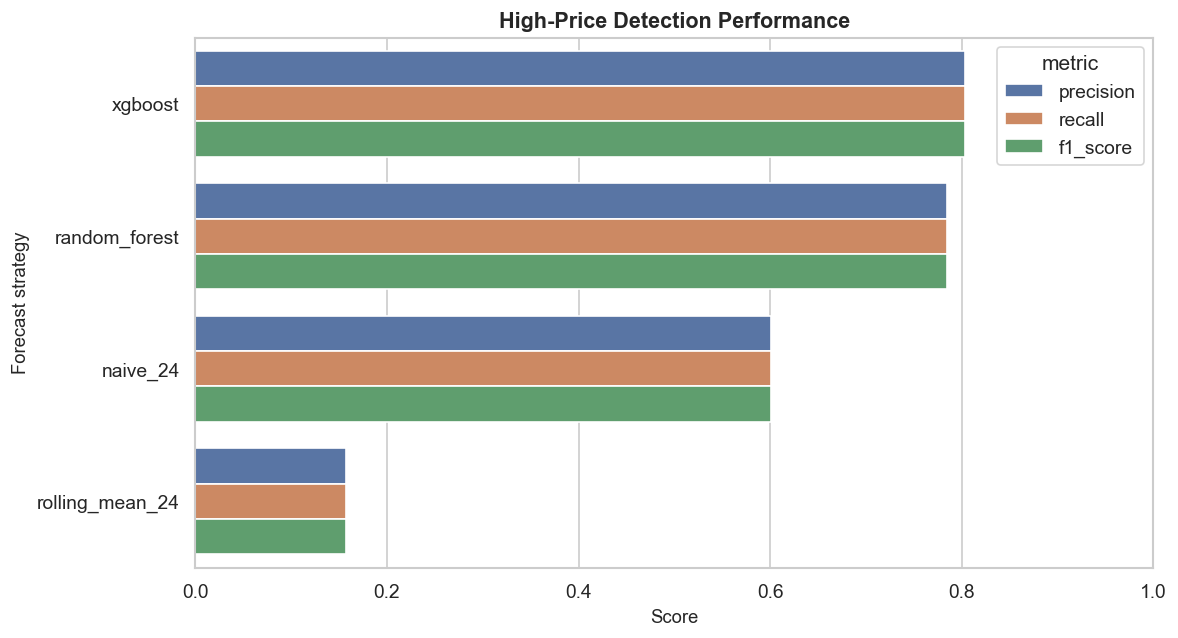

In [39]:

fig, ax = plt.subplots(figsize=(10, 5.5))

plot_df = high_price_detection_df.melt(
    id_vars="strategy",
    value_vars=["precision", "recall", "f1_score"],
    var_name="metric",
    value_name="score"
)

sns.barplot(
    data=plot_df,
    x="score",
    y="strategy",
    hue="metric",
    ax=ax
)

ax.set_title("High-Price Detection Performance")
ax.set_xlabel("Score")
ax.set_ylabel("Forecast strategy")
ax.set_xlim(0, 1)

fig.savefig(
    FIGURE_DIR / "high_price_detection_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



## 8. Directional accuracy

This evaluates whether the model correctly predicts whether the price will be higher or lower than the same hour on the previous day.

This is useful for decision support because many decisions depend on direction, not only exact price level.


In [41]:

def evaluate_directional_accuracy(
    frame: pd.DataFrame,
    forecast_col: str,
    reference_col: str = "naive_24"
) -> dict:
    """
    Evaluate whether the forecast correctly predicts price direction
    relative to a reference benchmark.
    """
    valid = frame[[forecast_col, "actual_price", reference_col]].dropna().copy()

    actual_direction = np.sign(
        valid["actual_price"] - valid[reference_col]
    )

    forecast_direction = np.sign(
        valid[forecast_col] - valid[reference_col]
    )

    # Remove cases with no actual change
    mask = actual_direction != 0

    return {
        "strategy": forecast_col,
        "directional_accuracy": accuracy_score(
            actual_direction[mask],
            forecast_direction[mask]
        )
    }


direction_results = []

for model_col in ["rolling_mean_24", "random_forest", "xgboost"]:
    direction_results.append(
        evaluate_directional_accuracy(
            frame=decision_data,
            forecast_col=model_col,
            reference_col="naive_24"
        )
    )

direction_accuracy_df = (
    pd.DataFrame(direction_results)
    .sort_values("directional_accuracy", ascending=False)
    .reset_index(drop=True)
)

display(direction_accuracy_df)

direction_accuracy_df.to_csv(
    RESULTS_DIR / "directional_accuracy_metrics.csv",
    index=False
)


,strategy,directional_accuracy
0,xgboost,0.907035
1,random_forest,0.900868
2,rolling_mean_24,0.646300


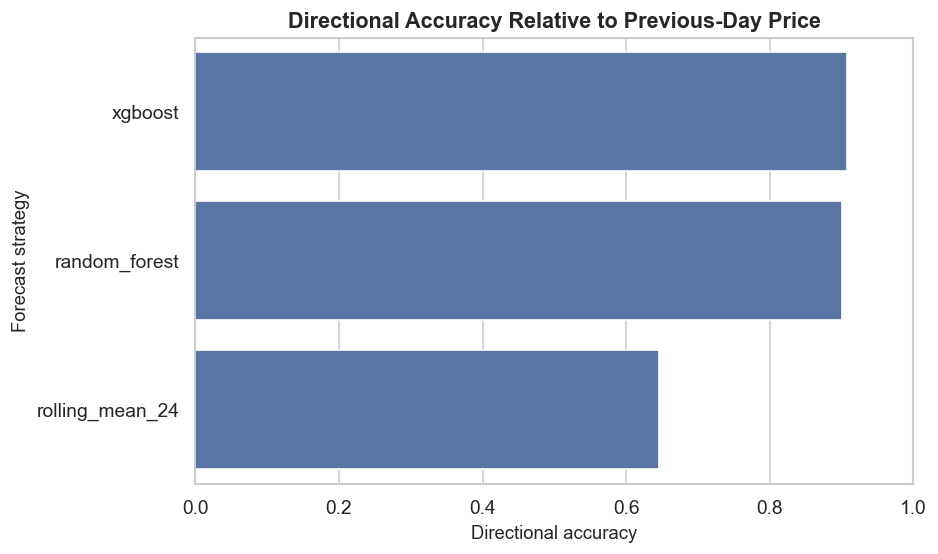

In [42]:

fig, ax = plt.subplots(figsize=(8, 4.8))

sns.barplot(
    data=direction_accuracy_df,
    x="directional_accuracy",
    y="strategy",
    ax=ax
)

ax.set_title("Directional Accuracy Relative to Previous-Day Price")
ax.set_xlabel("Directional accuracy")
ax.set_ylabel("Forecast strategy")
ax.set_xlim(0, 1)

fig.savefig(
    FIGURE_DIR / "directional_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



## 9. Build energy schedules from recommendations

This section converts recommendations into hourly energy schedules.

### Baseline schedule

- consume 1 MWh every hour.

### DSS schedule

- reduce consumption by 0.20 MWh in forecasted high-price hours;
- increase consumption by 0.20 MWh in forecasted low-price hours;
- keep normal consumption otherwise.

Daily energy remains unchanged.


In [44]:

def build_shifted_schedule(
    frame: pd.DataFrame,
    recommendation_col: str,
    base_load_mwh: float = 1.0,
    flex_mwh: float = 0.20
) -> pd.Series:
    """
    Build an hourly load schedule using DSS recommendations.

    Reduce/Avoid:
        base load - flexible amount

    Shift/Buy:
        base load + flexible amount

    Hold/Normal:
        base load
    """
    schedule = pd.Series(
        data=base_load_mwh,
        index=frame.index,
        dtype="float"
    )

    schedule.loc[
        frame[recommendation_col] == "Reduce / Avoid"
    ] = base_load_mwh - flex_mwh

    schedule.loc[
        frame[recommendation_col] == "Shift / Buy"
    ] = base_load_mwh + flex_mwh

    return schedule


# Baseline fixed schedule
decision_data["baseline_schedule_mwh"] = BASE_LOAD_MWH

# Schedules from forecast strategies
for model_col in BENCHMARK_MODELS:
    decision_data[f"{model_col}_schedule_mwh"] = build_shifted_schedule(
        frame=decision_data,
        recommendation_col=f"{model_col}_recommendation",
        base_load_mwh=BASE_LOAD_MWH,
        flex_mwh=FLEX_MWH_PER_SELECTED_HOUR
    )

# Oracle schedule: theoretical upper benchmark using actual prices
decision_data["oracle_recommendation"] = (
    decision_data["actual_price_regime"]
    .replace({
        "Actual High": "Reduce / Avoid",
        "Actual Low": "Shift / Buy",
        "Actual Normal": "Hold / Normal"
    })
)

decision_data["oracle_schedule_mwh"] = build_shifted_schedule(
    frame=decision_data,
    recommendation_col="oracle_recommendation",
    base_load_mwh=BASE_LOAD_MWH,
    flex_mwh=FLEX_MWH_PER_SELECTED_HOUR
)

schedule_columns = [
    "baseline_schedule_mwh"
] + [
    f"{model_col}_schedule_mwh" for model_col in BENCHMARK_MODELS
] + [
    "oracle_schedule_mwh"
]

display(decision_data[schedule_columns].head(48))


,baseline_schedule_mwh,naive_24_schedule_mwh,rolling_mean_24_schedule_mwh,random_forest_schedule_mwh,xgboost_schedule_mwh,oracle_schedule_mwh
2024-01-01 00:00:00+01:00,1.0,0.8,1.0,1.0,1.0,1.0
2024-01-01 01:00:00+01:00,1.0,1.0,1.0,1.0,1.0,1.0
2024-01-01 02:00:00+01:00,1.0,1.0,1.0,1.0,1.0,1.0
2024-01-01 03:00:00+01:00,1.0,1.2,1.0,1.0,1.2,1.0
2024-01-01 04:00:00+01:00,1.0,1.2,1.0,1.0,1.0,1.2
2024-01-01 05:00:00+01:00,1.0,1.0,1.0,1.0,1.0,1.2
2024-01-01 06:00:00+01:00,1.0,1.2,1.0,1.0,1.0,1.2
2024-01-01 07:00:00+01:00,1.0,1.2,1.0,1.2,1.0,1.2
2024-01-01 08:00:00+01:00,1.0,1.0,1.0,1.0,1.0,1.0
2024-01-01 09:00:00+01:00,1.0,1.0,1.0,1.2,1.2,1.0



## 10. Economic evaluation

Cost is calculated as:

\[
\text{hourly cost} = \text{scheduled energy (MWh)} \times \text{actual day-ahead price (EUR/MWh)}
\]

Savings are calculated against the fixed-load baseline.

\[
\text{savings} = \text{baseline cost} - \text{strategy cost}
\]

Positive savings mean the decision strategy reduced electricity procurement cost.


In [46]:

# Hourly costs
decision_data["baseline_cost_eur"] = (
    decision_data["baseline_schedule_mwh"]
    * decision_data["actual_price"]
)

for model_col in BENCHMARK_MODELS:
    decision_data[f"{model_col}_cost_eur"] = (
        decision_data[f"{model_col}_schedule_mwh"]
        * decision_data["actual_price"]
    )

decision_data["oracle_cost_eur"] = (
    decision_data["oracle_schedule_mwh"]
    * decision_data["actual_price"]
)

# Daily aggregation
daily_costs = (
    decision_data
    .assign(delivery_date=decision_data.index.date)
    .groupby("delivery_date")
    [[
        "baseline_cost_eur",
        "naive_24_cost_eur",
        "rolling_mean_24_cost_eur",
        "random_forest_cost_eur",
        "xgboost_cost_eur",
        "oracle_cost_eur"
    ]]
    .sum()
)

# Daily savings
for strategy in [
    "naive_24",
    "rolling_mean_24",
    "random_forest",
    "xgboost",
    "oracle"
]:
    daily_costs[f"{strategy}_savings_eur"] = (
        daily_costs["baseline_cost_eur"]
        - daily_costs[f"{strategy}_cost_eur"]
    )

display(daily_costs.head())

daily_costs.to_csv(
    RESULTS_DIR / "daily_costs_and_savings.csv"
)


,baseline_cost_eur,naive_24_cost_eur,rolling_mean_24_cost_eur,random_forest_cost_eur,xgboost_cost_eur,oracle_cost_eur,naive_24_savings_eur,rolling_mean_24_savings_eur,random_forest_savings_eur,xgboost_savings_eur,oracle_savings_eur
delivery_date,,,,,,,,,,,
2024-01-01,388.36,358.120,363.584,346.446,346.448,346.298,30.240,24.776,41.914,41.912,42.062
2024-01-02,1273.76,1244.646,1263.490,1224.310,1221.782,1219.180,29.114,10.270,49.450,51.978,54.580
2024-01-03,1085.16,1039.202,1149.518,1020.542,1020.556,1020.526,45.958,-64.358,64.618,64.604,64.634
2024-01-04,2049.84,1979.760,2007.030,1980.188,1980.188,1978.306,70.080,42.810,69.652,69.652,71.534
2024-01-05,2192.89,2169.294,2174.890,2170.076,2169.180,2168.398,23.596,18.000,22.814,23.710,24.492


In [47]:

def summarize_strategy_economics(
    daily_costs: pd.DataFrame,
    strategy: str
) -> dict:
    """
    Summarize economic value of a strategy.
    """
    baseline_total = daily_costs["baseline_cost_eur"].sum()
    strategy_total = daily_costs[f"{strategy}_cost_eur"].sum()
    savings_total = daily_costs[f"{strategy}_savings_eur"].sum()
    savings_pct = savings_total / baseline_total * 100

    daily_savings = daily_costs[f"{strategy}_savings_eur"]

    return {
        "strategy": strategy,
        "baseline_cost_eur": baseline_total,
        "strategy_cost_eur": strategy_total,
        "total_savings_eur": savings_total,
        "savings_percent": savings_pct,
        "average_daily_savings_eur": daily_savings.mean(),
        "median_daily_savings_eur": daily_savings.median(),
        "positive_savings_days": (daily_savings > 0).sum(),
        "total_days": len(daily_savings),
        "positive_savings_day_share": (daily_savings > 0).mean()
    }


economic_summary = []

for strategy in [
    "naive_24",
    "rolling_mean_24",
    "random_forest",
    "xgboost",
    "oracle"
]:
    economic_summary.append(
        summarize_strategy_economics(
            daily_costs=daily_costs,
            strategy=strategy
        )
    )

economic_summary_df = (
    pd.DataFrame(economic_summary)
    .sort_values("total_savings_eur", ascending=False)
    .reset_index(drop=True)
)

display(economic_summary_df)

economic_summary_df.to_csv(
    RESULTS_DIR / "economic_evaluation_summary.csv",
    index=False
)


,strategy,baseline_cost_eur,strategy_cost_eur,total_savings_eur,savings_percent,average_daily_savings_eur,median_daily_savings_eur,positive_savings_days,total_days,positive_savings_day_share
0,oracle,688159.24,662279.658,25879.582,3.760697,70.902964,63.190,365,365,1.000000
1,xgboost,688159.24,663304.546,24854.694,3.611765,68.095052,61.126,365,365,1.000000
2,random_forest,688159.24,663453.972,24705.268,3.590051,67.685666,59.672,365,365,1.000000
3,naive_24,688159.24,667823.072,20336.168,2.955154,55.715529,44.138,355,365,0.972603
4,rolling_mean_24,688159.24,686172.624,1986.616,0.288686,5.442784,4.670,208,365,0.569863


## 11. Visualise economic results

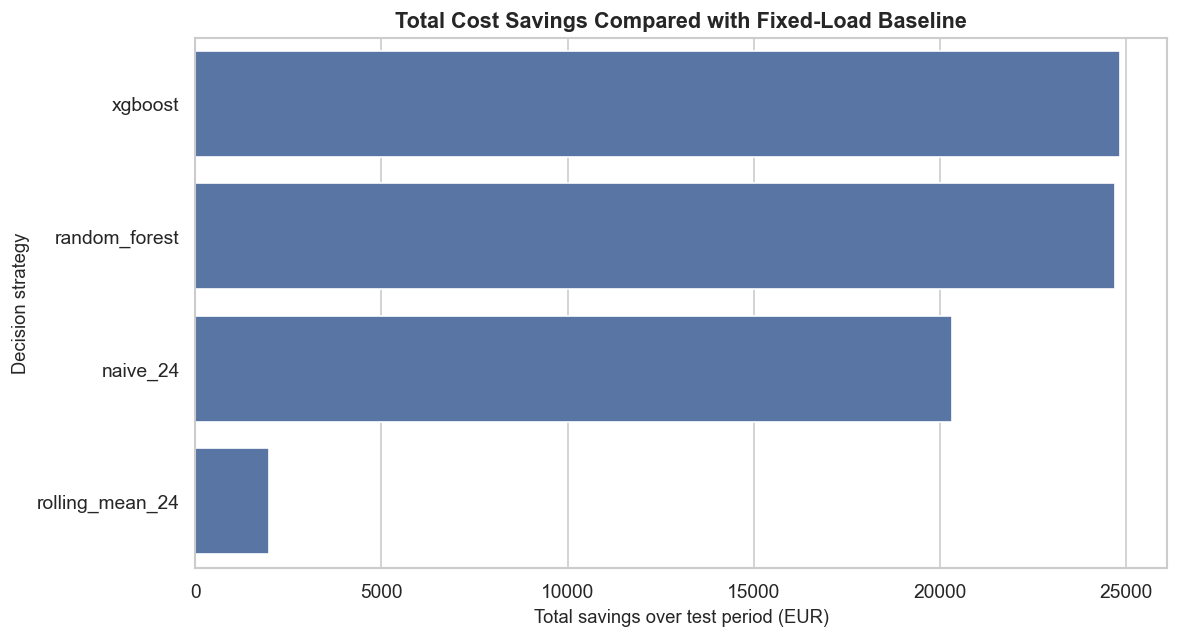

In [49]:

plot_df = economic_summary_df[
    economic_summary_df["strategy"] != "oracle"
].copy()

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.barplot(
    data=plot_df,
    x="total_savings_eur",
    y="strategy",
    ax=ax
)

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Total Cost Savings Compared with Fixed-Load Baseline")
ax.set_xlabel("Total savings over test period (EUR)")
ax.set_ylabel("Decision strategy")

fig.savefig(
    FIGURE_DIR / "total_cost_savings_by_strategy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


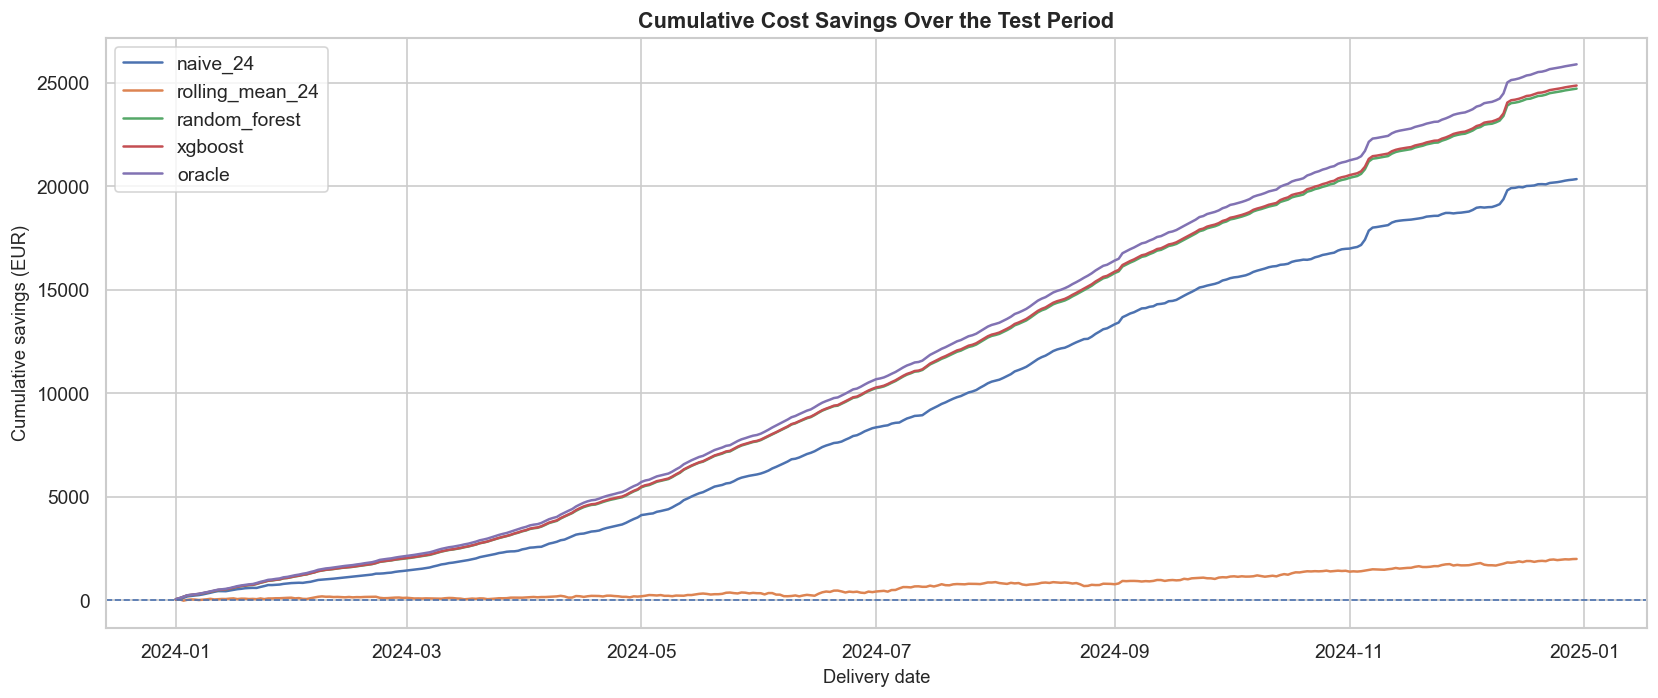

In [50]:

cumulative_savings = pd.DataFrame(index=daily_costs.index)

for strategy in [
    "naive_24",
    "rolling_mean_24",
    "random_forest",
    "xgboost",
    "oracle"
]:
    cumulative_savings[strategy] = (
        daily_costs[f"{strategy}_savings_eur"]
        .cumsum()
    )

fig, ax = plt.subplots(figsize=(14, 6))

for strategy in cumulative_savings.columns:
    ax.plot(
        cumulative_savings.index,
        cumulative_savings[strategy],
        label=strategy
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Cumulative Cost Savings Over the Test Period")
ax.set_xlabel("Delivery date")
ax.set_ylabel("Cumulative savings (EUR)")
ax.legend()

fig.savefig(
    FIGURE_DIR / "cumulative_cost_savings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


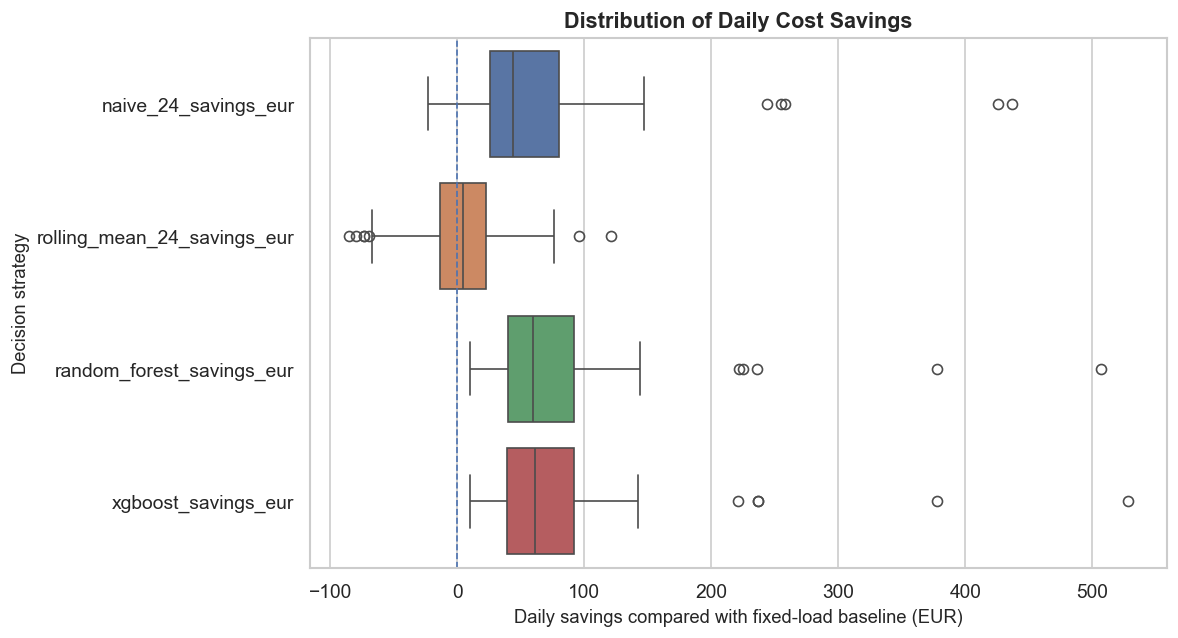

In [51]:

fig, ax = plt.subplots(figsize=(10, 5.5))

savings_columns = [
    "naive_24_savings_eur",
    "rolling_mean_24_savings_eur",
    "random_forest_savings_eur",
    "xgboost_savings_eur"
]

sns.boxplot(
    data=daily_costs[savings_columns],
    orient="h",
    ax=ax
)

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Distribution of Daily Cost Savings")
ax.set_xlabel("Daily savings compared with fixed-load baseline (EUR)")
ax.set_ylabel("Decision strategy")

fig.savefig(
    FIGURE_DIR / "daily_savings_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



## 12. Visualise XGBoost recommendations

This chart shows how XGBoost recommendations map onto actual prices for a selected period.


In [ ]:
# Make sure the index is a sorted DatetimeIndex before date slicing

decision_data = decision_data.copy()

decision_data.index = pd.to_datetime(
    decision_data.index,
    utc=True,
    errors="coerce"
)

decision_data = decision_data[~decision_data.index.isna()]

decision_data.index = decision_data.index.tz_convert("Europe/Berlin")

decision_data = decision_data.sort_index()

print(type(decision_data.index))
print("Is monotonic increasing:", decision_data.index.is_monotonic_increasing)
print("Start:", decision_data.index.min())
print("End:", decision_data.index.max())

(336, 24)
2024-01-01 00:00:00+01:00 2024-01-14 23:00:00+01:00


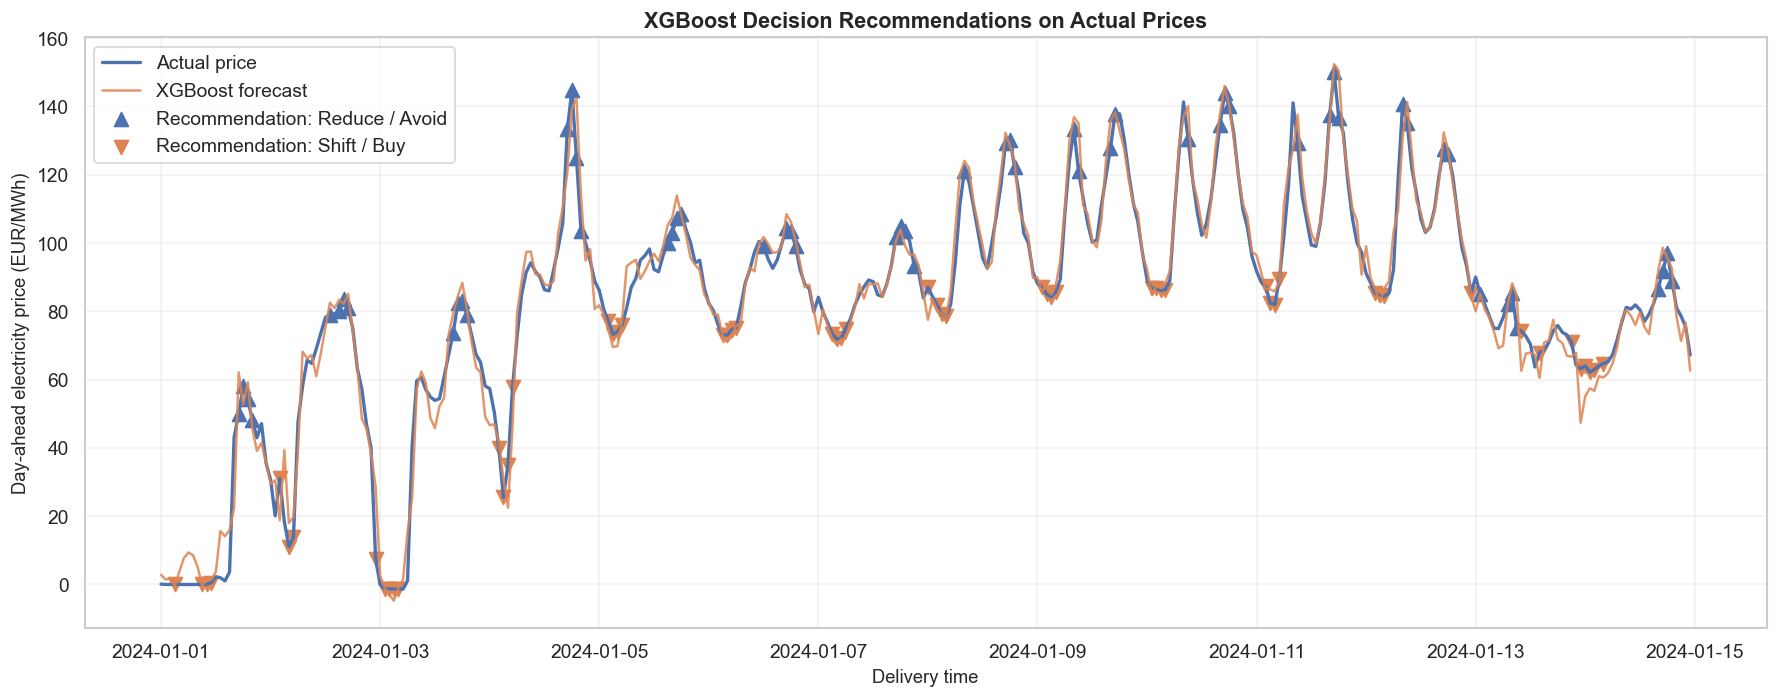

In [59]:
plot_start = pd.Timestamp("2024-01-01", tz="Europe/Berlin")
plot_end = pd.Timestamp("2024-01-14 23:59:59", tz="Europe/Berlin")

plot_data = decision_data[
    (decision_data.index >= plot_start)
    & (decision_data.index <= plot_end)
].copy()

print(plot_data.shape)
print(plot_data.index.min(), plot_data.index.max())


fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    plot_data.index,
    plot_data["actual_price"],
    label="Actual price",
    linewidth=2
)

ax.plot(
    plot_data.index,
    plot_data["xgboost"],
    label="XGBoost forecast",
    linewidth=1.5,
    alpha=0.85
)

reduce_points = plot_data[
    plot_data["xgboost_recommendation"] == "Reduce / Avoid"
]

shift_points = plot_data[
    plot_data["xgboost_recommendation"] == "Shift / Buy"
]

ax.scatter(
    reduce_points.index,
    reduce_points["actual_price"],
    marker="^",
    s=70,
    label="Recommendation: Reduce / Avoid"
)

ax.scatter(
    shift_points.index,
    shift_points["actual_price"],
    marker="v",
    s=70,
    label="Recommendation: Shift / Buy"
)

ax.set_title("XGBoost Decision Recommendations on Actual Prices")
ax.set_xlabel("Delivery time")
ax.set_ylabel("Day-ahead electricity price (EUR/MWh)")
ax.legend()
ax.grid(alpha=0.25)

fig.savefig(
    FIGURE_DIR / "xgboost_recommendations_on_price_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


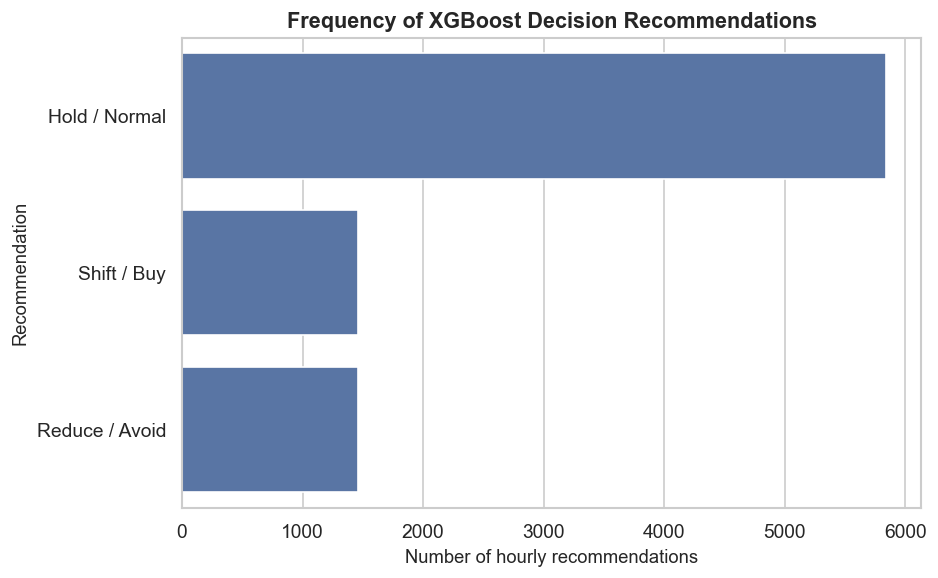

,recommendation,hours
0,Hold / Normal,5840
1,Shift / Buy,1460
2,Reduce / Avoid,1460


In [61]:

recommendation_counts = (
    decision_data["xgboost_recommendation"]
    .value_counts()
    .reset_index()
)

recommendation_counts.columns = [
    "recommendation",
    "hours"
]

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=recommendation_counts,
    x="hours",
    y="recommendation",
    ax=ax
)

ax.set_title("Frequency of XGBoost Decision Recommendations")
ax.set_xlabel("Number of hourly recommendations")
ax.set_ylabel("Recommendation")

fig.savefig(
    FIGURE_DIR / "xgboost_recommendation_counts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(recommendation_counts)


## 13. Confusion matrix for high-price detection

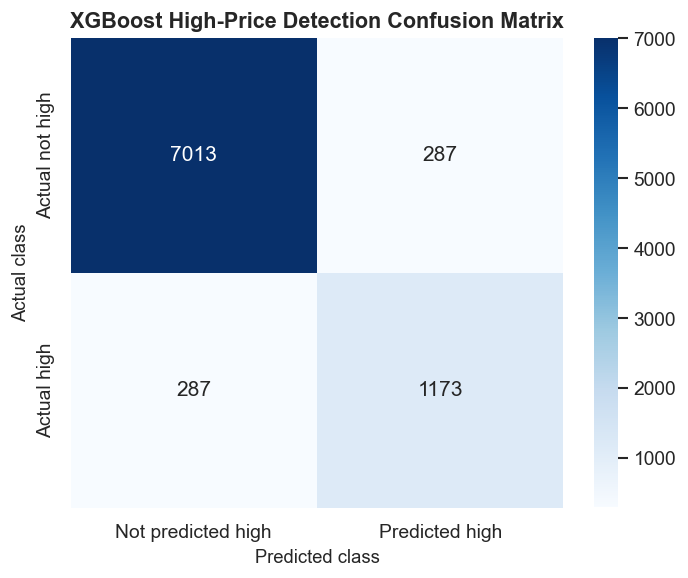

In [63]:

y_true_high = (
    decision_data["actual_price_regime"] == "Actual High"
).astype(int)

y_pred_high = (
    decision_data["xgboost_recommendation"] == "Reduce / Avoid"
).astype(int)

cm = confusion_matrix(
    y_true_high,
    y_pred_high
)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not predicted high", "Predicted high"],
    yticklabels=["Actual not high", "Actual high"],
    ax=ax
)

ax.set_title("XGBoost High-Price Detection Confusion Matrix")
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

fig.savefig(
    FIGURE_DIR / "xgboost_high_price_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



## 14. Export final decision-support dataset

This file can be used later for:

- dashboard development,
- report tables,
- sensitivity analysis,
- decision-support interface design.


In [65]:

decision_data.to_csv(
    RESULTS_DIR / "decision_support_hourly_dataset.csv"
)

print("Saved decision-support hourly dataset.")
print("Saved files are located in:", RESULTS_DIR)


Saved decision-support hourly dataset.
Saved files are located in: C:\Users\SherM\OneDrive\Documents\1. Thesis\Results\Decision_Support



## 15. Generate dashboard summary cards

These metrics are useful for a decision-support dashboard.


In [67]:

xgb_summary = economic_summary_df[
    economic_summary_df["strategy"] == "xgboost"
].iloc[0]

xgb_detection = high_price_detection_df[
    high_price_detection_df["strategy"] == "xgboost"
].iloc[0]

xgb_direction = direction_accuracy_df[
    direction_accuracy_df["strategy"] == "xgboost"
].iloc[0]

dashboard_cards = pd.Series({
    "Test period start": decision_data.index.min(),
    "Test period end": decision_data.index.max(),
    "Baseline cost (EUR)": xgb_summary["baseline_cost_eur"],
    "XGBoost strategy cost (EUR)": xgb_summary["strategy_cost_eur"],
    "XGBoost total savings (EUR)": xgb_summary["total_savings_eur"],
    "XGBoost savings (%)": xgb_summary["savings_percent"],
    "Positive savings day share": xgb_summary["positive_savings_day_share"],
    "High-price detection precision": xgb_detection["precision"],
    "High-price detection recall": xgb_detection["recall"],
    "High-price detection F1": xgb_detection["f1_score"],
    "Directional accuracy": xgb_direction["directional_accuracy"]
})

display(dashboard_cards)

dashboard_cards.to_csv(
    RESULTS_DIR / "dashboard_summary_cards.csv",
    header=["value"]
)


Test period start                 2024-01-01 00:00:00+01:00
Test period end                   2024-12-30 23:00:00+01:00
Baseline cost (EUR)                               688159.24
XGBoost strategy cost (EUR)                      663304.546
XGBoost total savings (EUR)                       24854.694
XGBoost savings (%)                                3.611765
Positive savings day share                              1.0
High-price detection precision                     0.803425
High-price detection recall                        0.803425
High-price detection F1                            0.803425
Directional accuracy                               0.907035
dtype: object


# Interpretation Guide for the Report

Use the results from this notebook to write the final decision-support section.

## What to discuss

1. **Decision logic**
   - Explain how forecasts were converted into Reduce / Avoid, Shift / Buy and Hold / Normal recommendations.

2. **Recommendation quality**
   - Discuss high-price detection precision, recall and F1 score.
   - Discuss directional accuracy.

3. **Economic value**
   - Compare the XGBoost strategy against the fixed-load baseline.
   - Compare XGBoost against naive and rolling benchmarks.
   - Treat the oracle strategy as the theoretical upper bound, not a real strategy.

4. **Limitations**
   - This is a scenario-based evaluation, not a full trading simulation.
   - It assumes perfect ability to shift a fixed amount of flexible load.
   - It excludes transaction costs, taxes, imbalance penalties and operational constraints.
   - The value of the DSS should be interpreted as indicative rather than definitive.

5. **Connection to RQ3 and RQ4**
   - RQ3 is addressed by comparing forecast-informed decisions with benchmark strategies.
   - RQ4 is addressed by quantifying whether the AI-based DSS produces measurable savings and decision-quality improvements.
